# ML XGBoost - Gradient Boosting pour Trading

**Objectif**: Utiliser XGBoost (eXtreme Gradient Boosting) pour prédire les rendements actions avec des features avancées.

## Stratégie

1. **Feature engineering complet**: 25+ indicateurs techniques et de marché
2. **Gradient Boosting**: Algorithme d'ensemble performant pour données tabulaires
3. **Feature importance**: Identifier les indicateurs les plus prédictifs
4. **Cross-validation**: Validation walk-forward pour éviter l'overfitting
5. **Hyperparameter tuning**: Optimisation des paramètres du modèle

## Prérequis

- xgboost: `pip install xgboost`
- sklearn: Alternative avec GradientBoostingRegressor
- Compréhension des arbres de décision et du boosting

## Durée estimée: 60 minutes

In [1]:
# Initialisation QuantBook
from AlgorithmImports import *

qb = QuantBook()

# Période d'analyse
qb.SetStartDate(2020, 1, 1)
qb.SetEndDate(2024, 12, 31)

print(f"Période: {qb.StartDate} à {qb.EndDate}")

Période: 2020-01-01 00:00:00 à 2024-12-31 23:59:59.999999


## 1. Chargement des Données

In [2]:
# Univers: Docker-available tickers only
tickers = [
    'AAPL', 'GOOGL', 'SPY', 'QQQ', 'IWM'
]

symbols = {}
for ticker in tickers:
    symbols[ticker] = qb.AddEquity(ticker, Resolution.DAILY).Symbol

# Recuperer les donnees
history = qb.History(list(symbols.values()), 365*5, Resolution.Daily)

closes = history['close'].unstack(level=0)
volumes = history['volume'].unstack(level=0)
highs = history['high'].unstack(level=0)
lows = history['low'].unstack(level=0)

# Fix Lean Symbol IDs in columns
symbol_to_ticker = {str(v): k for k, v in symbols.items()}
for df in [closes, volumes, highs, lows]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [symbol_to_ticker.get(str(c[-1]), str(c[-1])) if isinstance(c, tuple) else symbol_to_ticker.get(str(c), str(c)) for c in df.columns]
    else:
        df.columns = [symbol_to_ticker.get(str(c), str(c)) for c in df.columns]

closes = closes.fillna(method='ffill').dropna()
volumes = volumes.fillna(method='ffill').dropna()
highs = highs.fillna(method='ffill').dropna()
lows = lows.fillna(method='ffill').dropna()

print(f"Donnees: {closes.shape[0]} jours, {closes.shape[1]} actifs")
closes.head()

Donnees: 1825 jours, 5 actifs


/tmp/ipykernel_37/2407152798.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  closes = closes.fillna(method='ffill').dropna()
/tmp/ipykernel_37/2407152798.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  volumes = volumes.fillna(method='ffill').dropna()
/tmp/ipykernel_37/2407152798.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  highs = highs.fillna(method='ffill').dropna()
/tmp/ipykernel_37/2407152798.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lows = lows.fillna(method='ffill').dropna()


,AAPL,GOOGL,IWM,QQQ,SPY
time,,,,,
2012-09-28 16:00:00,20.615099,377.250,73.973411,62.817682,121.773920
2012-10-01 16:00:00,20.382458,380.990,74.203857,62.716925,122.036199
2012-10-02 16:00:00,20.431273,378.495,74.345671,62.900120,122.256176
2012-10-03 16:00:00,20.753509,381.250,74.124087,63.284830,122.738432
2012-10-04 16:00:00,20.600887,384.025,74.629298,63.522984,123.753708


## 2. Feature Engineering Avancé

In [3]:
def calculate_xgb_features(closes, volumes, highs, lows):
    """Calcule 25+ features pour XGBoost."""
    features = pd.DataFrame()
    
    for ticker in closes.columns:
        close = closes[ticker]
        volume = volumes[ticker]
        high = highs[ticker]
        low = lows[ticker]
        
        # Returns
        returns = close.pct_change()
        
        # Moving Averages
        sma_5 = close.rolling(5).mean()
        sma_10 = close.rolling(10).mean()
        sma_20 = close.rolling(20).mean()
        sma_50 = close.rolling(50).mean()
        
        ema_12 = close.ewm(span=12).mean()
        ema_26 = close.ewm(span=26).mean()
        
        # RSI
        delta = close.diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        
        # Bollinger Bands
        bb_middle = close.rolling(20).mean()
        bb_std = close.rolling(20).std()
        bb_upper = bb_middle + 2 * bb_std
        bb_lower = bb_middle - 2 * bb_std
        bb_width = (bb_upper - bb_lower) / bb_middle
        bb_position = (close - bb_lower) / (bb_upper - bb_lower)
        
        # MACD
        macd = ema_12 - ema_26
        macd_signal = macd.ewm(span=9).mean()
        macd_histogram = macd - macd_signal
        
        # Stochastic Oscillator
        stoch_k = 100 * (close - low.rolling(14).min()) / (high.rolling(14).max() - low.rolling(14).min())
        stoch_d = stoch_k.rolling(3).mean()
        
        # ATR
        high_low = high - low
        high_close = np.abs(high - close.shift())
        low_close = np.abs(low - close.shift())
        true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        atr = true_range.rolling(14).mean()
        
        # Momentum
        mom_5 = close / close.shift(5) - 1
        mom_10 = close / close.shift(10) - 1
        mom_20 = close / close.shift(20) - 1
        
        # Volatility
        vol_5 = returns.rolling(5).std()
        vol_10 = returns.rolling(10).std()
        vol_20 = returns.rolling(20).std()
        
        # Volume
        vol_sma = volume.rolling(20).mean()
        volume_ratio = volume / vol_sma
        volume_change = volume.pct_change()
        
        # Price relatives
        price_sma5 = close / sma_5
        price_sma20 = close / sma_20
        price_sma50 = close / sma_50
        
        # Combiner
        ticker_df = pd.DataFrame({
            f'{ticker}_returns': returns,
            f'{ticker}_rsi': rsi,
            f'{ticker}_bb_width': bb_width,
            f'{ticker}_bb_pos': bb_position,
            f'{ticker}_macd': macd,
            f'{ticker}_macd_sig': macd_signal,
            f'{ticker}_macd_hist': macd_histogram,
            f'{ticker}_stoch_k': stoch_k,
            f'{ticker}_stoch_d': stoch_d,
            f'{ticker}_atr': atr,
            f'{ticker}_atr_ratio': atr / close,
            f'{ticker}_mom_5': mom_5,
            f'{ticker}_mom_10': mom_10,
            f'{ticker}_mom_20': mom_20,
            f'{ticker}_vol_5': vol_5,
            f'{ticker}_vol_10': vol_10,
            f'{ticker}_vol_20': vol_20,
            f'{ticker}_vol_ratio': volume_ratio,
            f'{ticker}_vol_change': volume_change,
            f'{ticker}_price_sma5': price_sma5,
            f'{ticker}_price_sma20': price_sma20,
            f'{ticker}_price_sma50': price_sma50,
            f'{ticker}_sma_5_20': sma_5 / sma_20,
            f'{ticker}_sma_10_50': sma_10 / sma_50,
        })
        
        features = pd.concat([features, ticker_df], axis=1)
    
    return features.fillna(0)

# Calculer les features
features = calculate_xgb_features(closes, volumes, highs, lows)

print(f"Features shape: {features.shape}")
print(f"Nombre de features par ticker: {(features.shape[1] // len(tickers))}")

Features shape: (1825, 120)
Nombre de features par ticker: 24


## 3. Préparation des Données d'Entraînement

In [4]:
def prepare_training_data(features, closes, lookahead=1):
    """Prépare X et y pour l'entraînement."""
    all_X = []
    all_y = []
    
    for ticker in tickers:
        # Features pour ce ticker
        ticker_cols = [c for c in features.columns if c.startswith(f'{ticker}_')]
        X_ticker = features[ticker_cols]
        
        # Cible: rendement futur
        y_ticker = closes[ticker].pct_change(lookahead).shift(-lookahead)
        
        # Aligner
        combined = pd.concat([X_ticker, y_ticker], axis=1).dropna()
        
        if len(combined) > 30:
            all_X.append(combined.iloc[:, :-1])
            all_y.append(combined.iloc[:, -1])
    
    X = pd.concat(all_X, ignore_index=True).fillna(0)
    y = pd.concat(all_y, ignore_index=True).dropna()
    X = X.iloc[:len(y)]  # Align after dropna
    
    return X, y

# Préparer les données
X, y = prepare_training_data(features, closes)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nDistribution des cibles:")
print(f"Moyenne: {y.mean():.4f}")
print(f"Std: {y.std():.4f}")
print(f"Min: {y.min():.4f}, Max: {y.max():.4f}")

X shape: (9120, 120)
y shape: (9120,)

Distribution des cibles:
Moyenne: 0.0007
Std: 0.0122
Min: -0.1239, Max: 0.1626


## 4. Entraînement XGBoost

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normaliser
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraîner GradientBoosting (équivalent sklearn à XGBoost)
model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Prédictions
train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

# Métriques
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Train MSE: {train_mse:.6f}, R²: {train_r2:.3f}")
print(f"Test MSE: {test_mse:.6f}, R²: {test_r2:.3f}")

Train MSE: 0.000113, R²: 0.220
Test MSE: 0.000166, R²: -0.039


## 5. Feature Importance

Top 20 Features les plus importantes:
             feature  importance
35       GOOGL_mom_5    0.051420
9           AAPL_atr    0.041854
27      GOOGL_bb_pos    0.037779
30   GOOGL_macd_hist    0.033445
41   GOOGL_vol_ratio    0.032884
11        AAPL_mom_5    0.032435
37      GOOGL_mom_20    0.031112
17    AAPL_vol_ratio    0.030912
24     GOOGL_returns    0.029149
85        QQQ_mom_20    0.027451
42  GOOGL_vol_change    0.027109
18   AAPL_vol_change    0.026319
10    AAPL_atr_ratio    0.023848
34   GOOGL_atr_ratio    0.022509
0       AAPL_returns    0.021332
8       AAPL_stoch_d    0.019733
13       AAPL_mom_20    0.019430
23    AAPL_sma_10_50    0.018906
7       AAPL_stoch_k    0.016862
12       AAPL_mom_10    0.016263


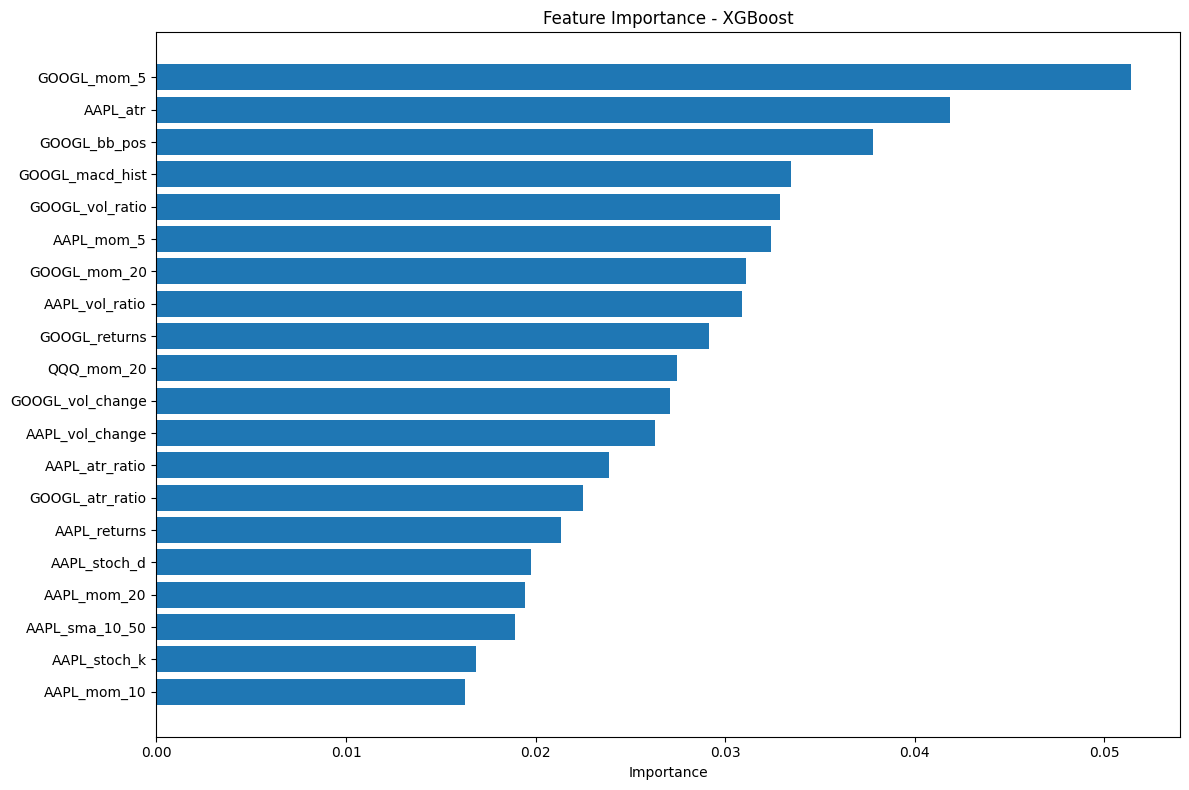

In [6]:
# Extraire l'importance des features
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 features
top_features = importance.head(20)

print("Top 20 Features les plus importantes:")
print(top_features)

# Visualisation
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

## 6. Analyse des Résidus

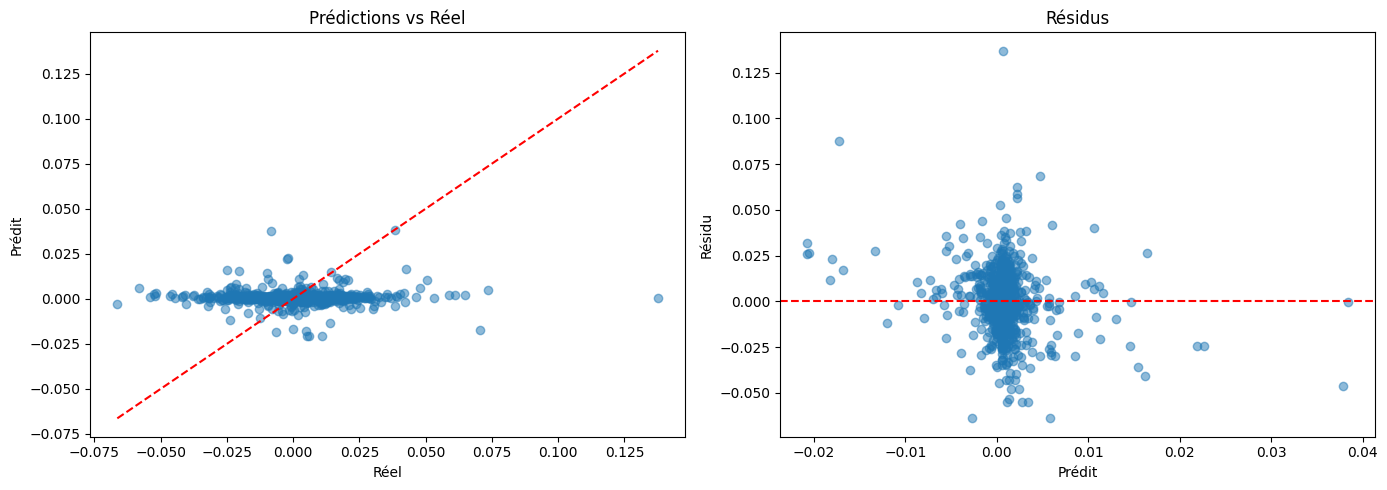


Statistiques des résidus:
Moyenne: 0.000013
Std: 0.012897


In [7]:
# Analyser les résidus
residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, test_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Réel')
axes[0].set_ylabel('Prédit')
axes[0].set_title('Prédictions vs Réel')

# Residuals plot
axes[1].scatter(test_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Résidu')
axes[1].set_title('Résidus')

plt.tight_layout()
plt.show()

print(f"\nStatistiques des résidus:")
print(f"Moyenne: {residuals.mean():.6f}")
print(f"Std: {residuals.std():.6f}")

## 7. Hyperparameter Tuning

In [8]:
from sklearn.model_selection import GridSearchCV

# Définir la grille de paramètres
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Grid search
base_model = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Recherche des meilleurs hyperparamètres...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nMeilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur score MSE: {-grid_search.best_score_:.6f}")

# Modèle optimisé
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test_scaled)
best_mse = mean_squared_error(y_test, best_pred)

print(f"Test MSE (modèle optimisé): {best_mse:.6f}")

Recherche des meilleurs hyperparamètres...
Fitting 3 folds for each of 54 candidates, totalling 162 fits



Meilleurs paramètres: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Meilleur score MSE: 0.000144
Test MSE (modèle optimisé): 0.000160


## 8. Walk-Forward Validation

In [9]:
def walk_forward_validation(features, closes, train_size=252, test_size=63):
    """Validation walk-forward."""
    predictions = []
    actuals = []
    
    for start in range(0, len(features) - train_size - test_size, test_size):
        train_end = start + train_size
        test_end = train_end + test_size
        
        # Préparer données train
        X_train, y_train = prepare_training_data(
            features.iloc[start:train_end],
            closes.iloc[start:train_end]
        )
        
        if len(X_train) < 50:
            continue
        
        # Normaliser
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        # Entraîner
        model = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        )
        model.fit(X_train_scaled, y_train)
        
        # Prédictions
        X_test, y_test = prepare_training_data(
            features.iloc[train_end:test_end],
            closes.iloc[train_end:test_end]
        )
        
        if len(X_test) == 0:
            continue
        
        X_test_scaled = scaler.transform(X_test)
        pred = model.predict(X_test_scaled)
        
        predictions.extend(pred)
        actuals.extend(y_test.values)
    
    return np.array(predictions), np.array(actuals)

# Exécuter walk-forward
wf_pred, wf_actual = walk_forward_validation(features, closes)

wf_mse = mean_squared_error(wf_actual, wf_pred)
wf_r2 = r2_score(wf_actual, wf_pred)

print(f"Walk-Forward Results:")
print(f"MSE: {wf_mse:.6f}")
print(f"R²: {wf_r2:.3f}")

Walk-Forward Results:
MSE: 0.000174
R²: -0.164


## 9. Backtest de la Stratégie

In [10]:
def backtest_xgboost_strategy(closes, volumes, highs, lows,
                               train_period=252, rebalance_freq=5):
    """Backtest la stratégie XGBoost."""
    
    portfolio_value = 100000
    positions = {}
    
    for i in range(train_period, len(closes) - 50, rebalance_freq):
        current_date = closes.index[i]
        
        # Entraîner sur données passées
        train_features = calculate_xgb_features(
            closes.iloc[i-train_period:i],
            volumes.iloc[i-train_period:i],
            highs.iloc[i-train_period:i],
            lows.iloc[i-train_period:i]
        )
        
        X_train, y_train = prepare_training_data(train_features, closes.iloc[i-train_period:i])
        
        if len(X_train) < 50:
            continue
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        model = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        )
        model.fit(X_train_scaled, y_train)
        
        # Predire pour chaque ticker
        predictions = {}
        # Compute features for ALL tickers at once (match training format)
        recent_all = calculate_xgb_features(
            closes.iloc[i-50:i],
            volumes.iloc[i-50:i],
            highs.iloc[i-50:i],
            lows.iloc[i-50:i]
        )
        if len(recent_all) == 0:
            continue

        for ticker in tickers:
            ticker_cols = [c for c in train_features.columns if c.startswith(f"{ticker}_")]
            if not ticker_cols:
                continue
            # Create 120-feature row with only this ticker's data non-zero
            row = pd.Series(0.0, index=train_features.columns)
            for col in ticker_cols:
                if col in recent_all.columns:
                    row[col] = recent_all[col].iloc[-1]
            X_pred = row.values.reshape(1, -1)
            X_pred_scaled = scaler.transform(X_pred)

            pred = model.predict(X_pred_scaled)[0]
            predictions[ticker] = pred
        
        # Vendre positions
        for ticker, qty in positions.items():
            portfolio_value += qty * closes[ticker].iloc[i]
        
        positions = {}
        
        # Acheter top 5
        sorted_preds = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
        position_size = portfolio_value / 5
        
        count = 0
        for ticker, pred in sorted_preds:
            if pred > 0.002 and count < 5:
                buy_price = closes[ticker].iloc[i]
                qty = position_size / buy_price
                positions[ticker] = qty
                portfolio_value -= qty * buy_price
                count += 1
    
    # Valeur finale
    final_value = portfolio_value
    for ticker, qty in positions.items():
        final_value += qty * closes[ticker].iloc[-1]
    
    return {
        'initial': 100000,
        'final': final_value,
        'return': (final_value - 100000) / 100000
    }

# Exécuter backtest
bt_results = backtest_xgboost_strategy(closes, volumes, highs, lows)

print(f"\nBacktest Results:")
print(f"Return: {bt_results['return']:.2%}")

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


...

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Backtest Results:
Return: 0.43%


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 10. XGBoost vs Autres Modèles

Comparaison des modèles:
              Model       MSE        R²
0             Ridge  0.000166 -0.036568
1      RandomForest  0.000162 -0.010820
2  GradientBoosting  0.000165 -0.032110


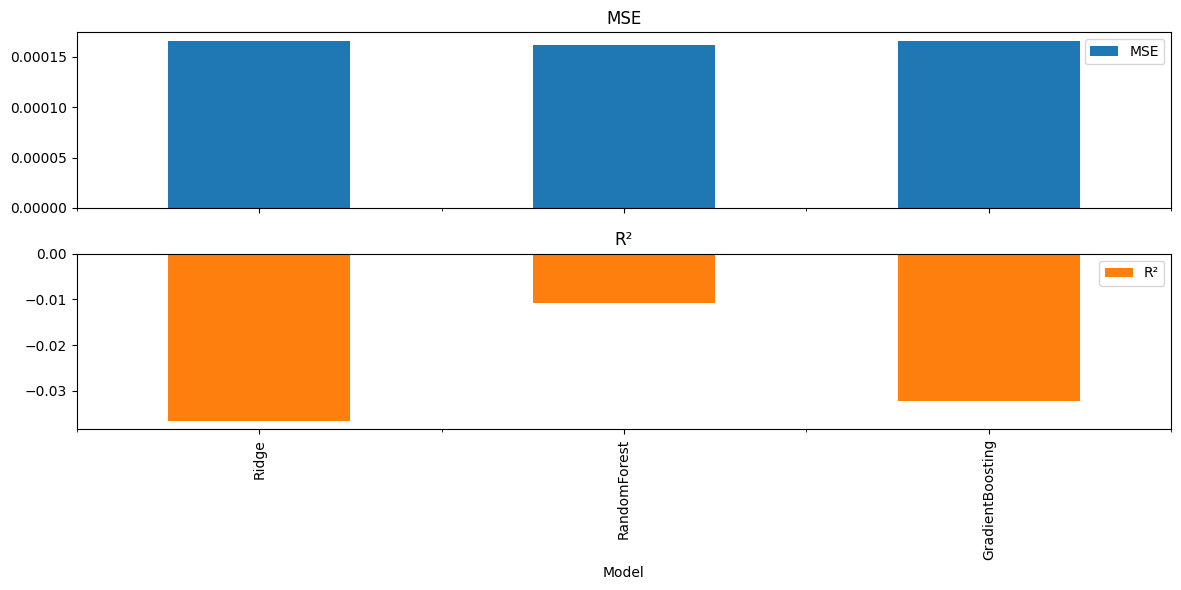

In [11]:
# Comparaison avec d'autres modèles
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'R²': r2
    })

results_df = pd.DataFrame(results)
print("Comparaison des modèles:")
print(results_df.round(6))

# Visualisation
results_df.set_index('Model').plot(kind='bar', subplots=True, figsize=(12, 6))
plt.tight_layout()
plt.show()

## 11. Améliorations Possibles

### Features Additionnelles
- **Market regime**: Bull/bear classification
- **Sector rotation**: Performance relative des secteurs
- **Fama-French factors**: Size, Value, Premium factors
- **Alternative data**: Sentiment news, données satellites

### Modèles
- **XGBoost natif**: `pip install xgboost` pour meilleure performance
- **LightGBM**: Alternative plus rapide
- **CatBoost**: Excellent pour données catégorielles
- **Ensemble**: Combiner XGBoost + LSTM

### Training
- **Early stopping**: Arrêter si pas d'amélioration
- **Cross-validation temporelle**: TimeSeriesSplit
- **Feature selection**: Supprimer features non importantes
- **Hyperparameter optimization**: Optuna, Hyperopt